# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [15]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

import torch
from torch.autograd import Variable
from torch.nn import functional as F

# Justifying trial type > instatanous state > instatanous speed

## Set up for 14 conditions and 6 areas 

probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [4]:
# Use self trained K-means results, which have a better likelihood
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [5]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

mean_num_neuron = []
for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id']==0)]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons in cross-pop in average. ")
    mean_num_neuron.append(np.mean(num_cross_pop))

probeA has 12.225 neurons in cross-pop in average. 
probeB has 14.95 neurons in cross-pop in average. 
probeC has 16.9 neurons in cross-pop in average. 
probeD has 10.625 neurons in cross-pop in average. 
probeE has 7.375 neurons in cross-pop in average. 
probeF has 8.225 neurons in cross-pop in average. 


In [6]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

num_neuron = []
for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id'].isin([0,1,2]))]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons. ")
    num_neuron.append(np.mean(num_cross_pop))

probeA has 64.0 neurons. 
probeB has 60.0 neurons. 
probeC has 85.0 neurons. 
probeD has 53.0 neurons. 
probeE has 53.0 neurons. 
probeF has 37.0 neurons. 


In [85]:
# Load LFP data
start_time = 0.0
end_time = 0.5
padding = 0.5
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## No speed

Used 99 steps to converge. 
loss: 65147.70441567991
intecept:-0.013; coef:-0.088
loss increased!
Used 99 steps to converge. 
loss: 62461.99298954035
intecept:-0.018; coef:-0.113
loss increased!
Used 99 steps to converge. 
loss: 62289.710976783506
intecept:-0.019; coef:-0.123
loss increased!
Used 99 steps to converge. 
loss: 62296.36043954281
intecept:-0.020; coef:-0.129
loss increased!
Used 99 steps to converge. 
loss: 62340.76373469019
intecept:-0.021; coef:-0.133
loss increased!
Used 99 steps to converge. 
loss: 62279.58710909003
intecept:-0.022; coef:-0.136
loss increased!
Used 99 steps to converge. 
loss: 62285.99594272897
intecept:-0.020; coef:-0.131
loss increased!
Used 99 steps to converge. 
loss: 62295.99524897524
intecept:-0.020; coef:-0.130
loss increased!
Used 99 steps to converge. 
loss: 62296.68401224885
intecept:-0.020; coef:-0.130
loss increased!
Used 99 steps to converge. 
loss: 62295.88496255739
intecept:-0.020; coef:-0.130
loss increased!
Used 99 steps to converge. 
l

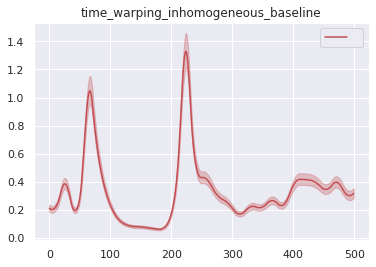

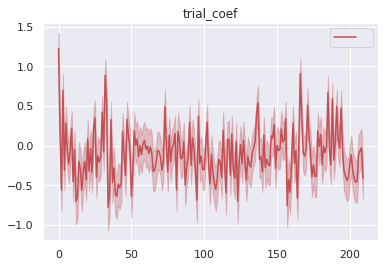

In [106]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)
# select_trials = V1.running_trial_index

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', method='pytorch', verbose=False, max_iter=10, penalty=penalty)
# model.fit('probeC', method='pytorch', verbose=False, penalty=penalty)

baseline_aic = model.aic
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

Used 99 steps to converge. 
loss: 65156.87946076858
loss increased!
Used 99 steps to converge. 
loss: 62491.68406232819
loss increased!
Used 99 steps to converge. 
loss: 62320.07975016903
loss increased!
Used 99 steps to converge. 
loss: 62331.331784955386
loss increased!
Used 99 steps to converge. 
loss: 62387.32053778452
loss increased!
Used 99 steps to converge. 
loss: 62311.767598298306
loss increased!
Used 99 steps to converge. 
loss: 62321.935481588866
loss increased!
Used 99 steps to converge. 
loss: 62331.40634844552
loss increased!
Used 99 steps to converge. 
loss: 62331.21853736349
loss increased!
Used 99 steps to converge. 
loss: 62331.21853736349
loss increased!
Used 99 steps to converge. 
loss: 62331.21853736349
AIC improvement of the model is: 0.0


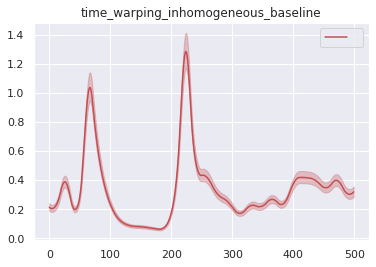

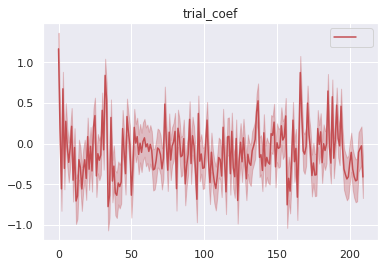

In [84]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)
# select_trials = V1.running_trial_index

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', method='pytorch', verbose=False, max_iter=10, penalty=penalty)
# model.fit('probeC', method='pytorch', verbose=False, penalty=penalty)

baseline_aic = model.aic
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

## Simple linear term of speed

AIC improvement of the model is: 19.525719638855662


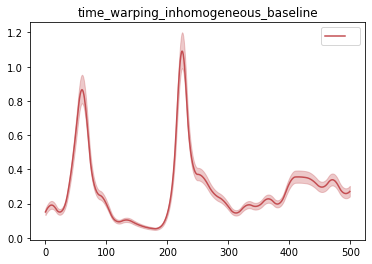

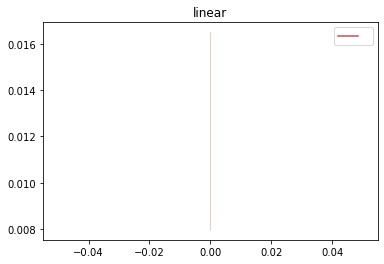

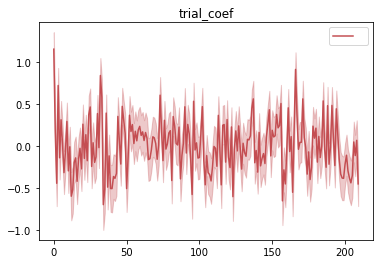

In [944]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('linear', smo, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

## Simple binary term of state

AIC improvement of the model is: 11.377192939427914


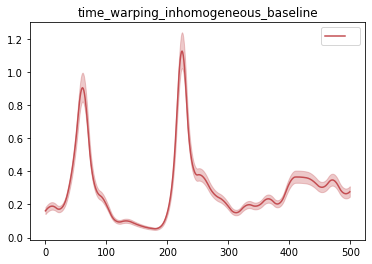

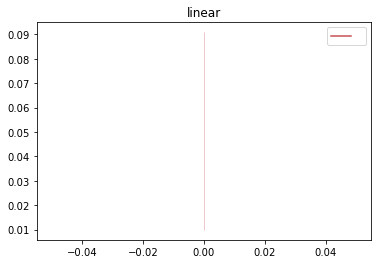

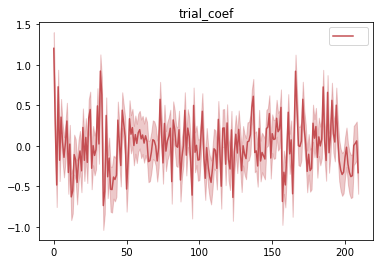

In [945]:
best_time_diff = 0
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
threshold = 1
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('linear', instantaneous_state, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

## Time-varying linear term of speed

AIC improvement of the model is: 1435.807935162331


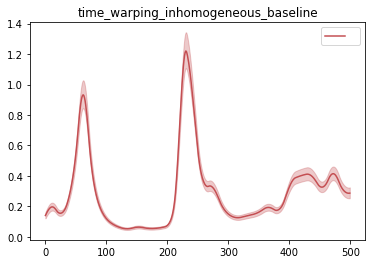

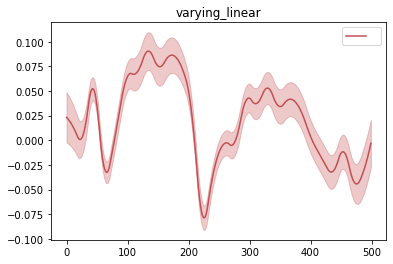

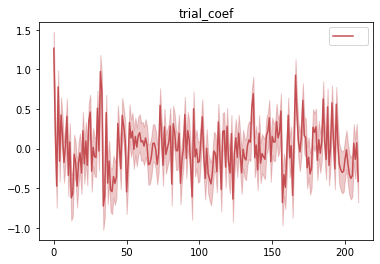

In [946]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('varying_linear', smo, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

## Time-varying instantaneous binary term of state

AIC improvement of the model is: 1848.2833519917913


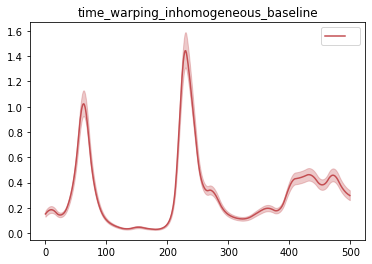

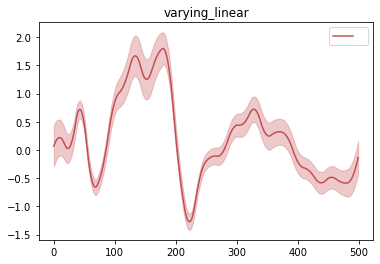

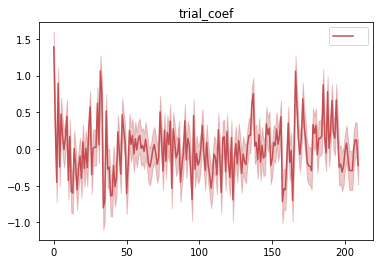

In [958]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
instantaneous_state = np.zeros_like(smo)
instantaneous_state[smo>threshold] = 1
model.add_effect('varying_linear', instantaneous_state, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

## Time-varying Trial-wise binary term of state

AIC improvement of the model is: 2363.687547071997


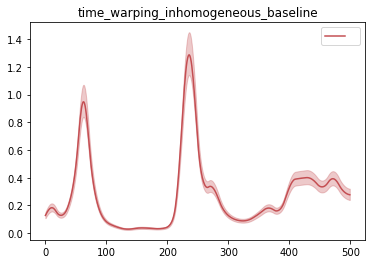

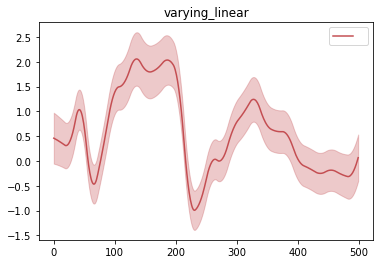

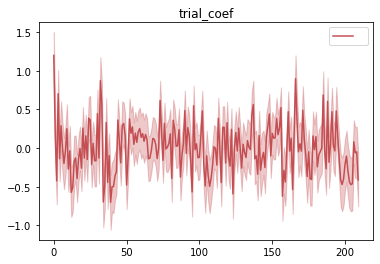

In [959]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)

trial_state = np.zeros_like(V1.speed)
for i in range(trial_state.shape[1]):
    if V1.running_trial_index[i]:
        trial_state[:,i] = 1.0

model.add_effect('varying_linear', trial_state, num=num_varying_linear, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

In [964]:
### 90% of the elements are the same in tria-wise state and instantaneous state
np.sum(trial_state == instantaneous_state)/(trial_state.shape[0]*trial_state.shape[1])

0.8979333333333334

## Two-way couping

AIC improvement of the model is: 173.63806043994555


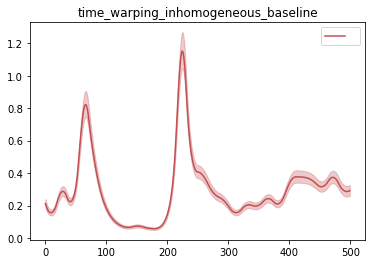

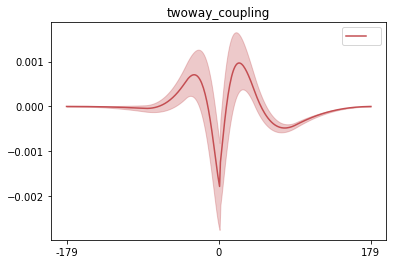

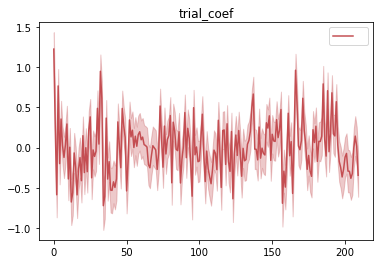

In [949]:
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
penalty = 3e-1

select_trials = np.full(V1.ntrial, True)

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
smo = utils.kernel_smoothing(V1_wider.speed, 
                             smooth_std)[(500+best_time_diff):(1000+best_time_diff),select_trials]
model.add_effect('twoway_coupling', smo, peaks_max=40, num=3, nonlinear=0.4, apply_no_penalty=True)
model.add_effect('trial_coef')
model.fit_time_warping_baseline('probeC', verbose=False, max_iter=10, penalty=penalty)
print(f"AIC improvement of the model is: {2*(baseline_aic - model.aic)}")
GLM.plot_GLM_compare(model)

# Justify coupling effects should contain history effects with 1st/2nd order interaction terms or just 2nd order term of Lambda

## Baseline (no coupling)

In [288]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
# for j, input_probe in enumerate(probe_list):
#     model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
# for j, input_probe in enumerate(probe_list):
#     model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

baseline_aic = model_running.aic + model_stationary.aic
print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

36637.202062489836
33987.18594550881
33892.111830880014
33884.697406844345
33880.534160698655
33881.55785218402
33881.55785218402
33881.55785218402
33881.55785218402
33881.55785218402
33881.55785218402
27427.60986825877
27080.064322789596
27073.303879906718
27052.972247805108
27033.360313113775
27026.442357860768
27019.404542069227
27015.737332193865
27016.543284815296
27042.614010812613
27050.307819634796
AIC improvement of the model is: 0.0


/tmp/ipykernel_59720/3690372901.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


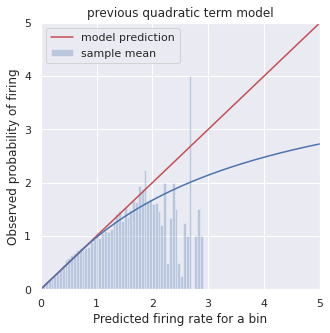

In [293]:
model_list = [model_stationary, model_running]

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.title('previous quadratic term model')

xx = np.linspace(np.log(1e-3), np.log(5), 1000)
plt.plot(np.exp(xx), np.exp(GLM.f_correct(xx, a=-0.15, intecept=-0.4)))

In [279]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
# for j, input_probe in enumerate(probe_list):
#     model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, method='additional', verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
# for j, input_probe in enumerate(probe_list):
#     model_running.add_effect('coupling', probe_list[j], **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, method='additional', verbose=False, max_iter=max_iter, penalty=penalty)

baseline_aic = model_running.aic + model_stationary.aic
print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

after beta updating: 36636.77023
update learning_rate: 0.002
update learning_rate: 0.0004
update learning_rate: 8e-05
update learning_rate: 1.6000000000000003e-05
update learning_rate: 3.2000000000000007e-06
update learning_rate: 6.400000000000002e-07
update learning_rate: 1.2800000000000006e-07
update learning_rate: 2.5600000000000014e-08
update learning_rate: 5.120000000000003e-09
update learning_rate: 1.0240000000000006e-09
update learning_rate: 2.0480000000000014e-10
update learning_rate: 4.096000000000003e-11
update learning_rate: 8.192000000000007e-12
update learning_rate: 1.6384000000000016e-12
after a and intecept updating: 36636.77023
after beta updating: 36636.77023
update learning_rate: 0.002
update learning_rate: 0.0004
update learning_rate: 8e-05
update learning_rate: 1.6000000000000003e-05
update learning_rate: 3.2000000000000007e-06
update learning_rate: 6.400000000000002e-07
update learning_rate: 1.2800000000000006e-07
update learning_rate: 2.5600000000000014e-08
update

after beta updating: 27010.53380
update learning_rate: 0.002
update learning_rate: 0.0004
update learning_rate: 0.002
update learning_rate: 0.0004
after a and intecept updating: 27010.52694
after beta updating: 27010.53380
update learning_rate: 0.002
update learning_rate: 0.0004
update learning_rate: 0.002
update learning_rate: 0.0004
after a and intecept updating: 27010.52694
-6.4391831394400265 6.4391831394400265
-6.4391831394400265
27010.33715828485
27010.402600574424
27010.468148268483
27010.53380144862
27010.526942671906
after beta updating: 27036.93869
update learning_rate: 0.002
update learning_rate: 0.0004
update learning_rate: 0.002
update learning_rate: 0.0004
after a and intecept updating: 27036.93091
after beta updating: 27036.93869
update learning_rate: 0.002
update learning_rate: 0.0004
update learning_rate: 0.002
update learning_rate: 0.0004
after a and intecept updating: 27036.93091
-6.0988093891033435 6.0988093891033435
-6.0988093891033435
27036.75243810785
27036.81442

/tmp/ipykernel_59720/2784432478.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


Text(0.5, 1.0, 'previous quadratic term model')

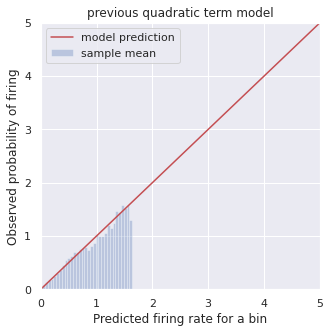

In [219]:
model_list = [model_stationary, model_running]

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.title('previous quadratic term model')

## Only cross-area coupling

In [185]:
# The following hyperparameters turned out to be the best

max_iter = 2
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    if j == 2:
        continue
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, method='pytorch', verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    if j == 2:
        continue
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, method='pytorch', verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

ran for full epoch and still not converge!
loss: 33211.715
intecept:-0.0726659; coef:-0.0059197
ran for full epoch and still not converge!
loss: 31977.001
intecept:-0.0731325; coef:-0.0059393
ran for full epoch and still not converge!
loss: 31991.725
intecept:-0.0732274; coef:-0.0059351
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
ran for full epoch and still not converge!
loss: 30589.500
intecept:0.0000000; coef:0.0000000
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
ran for full epoch and still not converge!
loss: 30245.581
intecept:0.0000274; coef:-0.0000092
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
ran for full epoch and still not converge!
loss: 30238.801
intecept:0.0000274; coef:-0.0000082
AIC improvement of the model

In [81]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    if j == 2:
        continue
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    if j == 2:
        continue
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

33196.32465851653
31943.59023392944
31943.075358583672
31873.840333426608
31822.869429566872
31823.164960397295
31825.633702023286
31821.907336307024
31814.174435225246
31821.11197519097
31821.870873823314
26887.00823103364
26616.966562022735
26619.639903709103
26615.542497946484
26613.31995534164
26613.88393320444
26614.522697792672
26614.353739571205
26614.235955137163
26613.1242382008
26612.53480984102
AIC improvement of the model is: 4873.721800976338


## Both cross-area coupling and history

This is unstable when doing simulation

In [16]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':30, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 6565.627360909144


## With interaction in history effect

In [27]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 9095.523639194791


In [30]:
previous_shifts_stationary = model_stationary.shifts
previous_shifts_running = model_running.shifts

## With only 2nd interaction in history effect

In [33]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 8433.76611839507


## With both 1st and 2nd interaction in history effect

In [34]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 9585.684321651519


## With $\Lambda$ in history effect

In [35]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 6945.116438797515


## With $\Lambda^{1.5}$ refractory in history effect

In [302]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

baseline_aic = aic

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")

6it [02:37, 26.27s/it]

AIC improvement of the model is: 0.0


/tmp/ipykernel_59720/1076785511.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


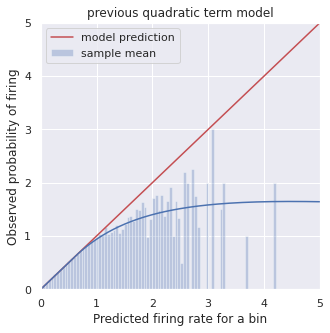

In [303]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.title('previous quadratic term model')

xx = np.linspace(np.log(1e-3), np.log(5), 1000)
plt.plot(np.exp(xx), np.exp(GLM.f_correct(xx, a=-0.25, intecept=-0.5)))

## With $\Lambda^2$ refractory in history effect

In [100]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, method='pytorch', verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('refractory', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, method='pytorch', verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss inc

loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss inc

loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss inc

loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
Used 99 steps to converge. 
loss: 42849.56458987515
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss

loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
Used 99 steps to converge. 
loss: 42840.12302563545
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss increased!
loss

In [ ]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])
plt.title('previous quadratic term model')

## Interaction in all coupling effects

Not so good

In [55]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('interaction', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params,apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('interaction', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params,apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 8574.478131664648


## refractory nonparametric

In [12]:
ihbasis.shape

(158, 10)

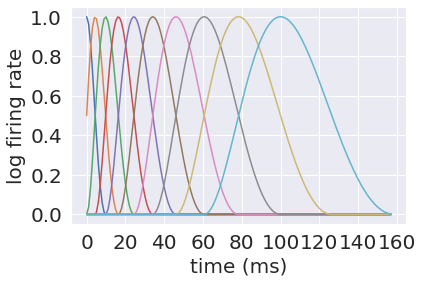

In [11]:
num=10
peaks_min=0
peaks_max=100
nonlinear=0.2
dt=1

nonlinear = nonlinear*peaks_max
nlin = lambda x: np.log(x+1e-10)
invnl = lambda x: np.exp(x)-1e-10
hpeaks = np.array([peaks_min, peaks_max])
yrnge = nlin(hpeaks+nonlinear)

db = np.diff(yrnge)[0]/(num-1)
ctrs = np.linspace(yrnge[0], yrnge[1], num)[None,:]
mxt = (invnl(yrnge[1]+2*db)-nonlinear).astype(int)
iht = np.arange(0,mxt,dt)[:,None]
nt = len(iht)
ff = lambda x, c, dc: (np.cos(np.maximum(-np.pi,np.minimum(np.pi, (x-c)*np.pi/dc/2)))+1)/2
ihbasis = ff(np.tile(nlin(iht+nonlinear), (1, num)), np.tile(ctrs, (nt, 1)), db)

fontsize = 20
plt.figure()
plt.plot(ihbasis, '-')
plt.ylabel('log firing rate',fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize) 
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.show()

## Final chosen model

In [997]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
target_probe = 'probeC'
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

select_trials = V1.stationary_trial_index
model_stationary = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', probe_list[j], tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_stationary.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_stationary.add_effect('trial_coef')
model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

select_trials = V1.running_trial_index
model_running = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
for j, input_probe in enumerate(probe_list):
    model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', probe_list[j], tau=tau, order=2, **coupling_filter_params, apply_no_penalty=True)
# model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params)
# model_running.add_effect('interaction', target_probe, tau=tau, order=2, **coupling_filter_params)
model_running.add_effect('trial_coef')
model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)

print(f"AIC improvement of the model is: {2*(baseline_aic - model_running.aic - model_stationary.aic)}")

AIC improvement of the model is: 8811.665204589794


# Plot $\Lambda$

In [726]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=1, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [03:22, 33.72s/it]

AIC improvement of the model is: -4867.640643246239


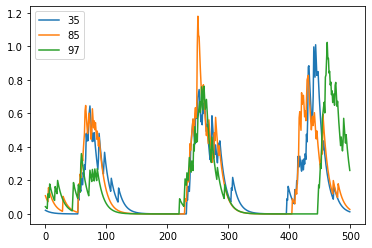

In [735]:
to_look_at = 3
model = stationary_model_list[to_look_at]
for i in range(0, 100):
    to_plot = model.effect_list[7].reshape((model.nt, model.ntrial), order='F')[:,i]
    if to_plot.max() >= 1:
        plt.plot(to_plot, label=str(i))
plt.legend()

# Without Additional layer

In [541]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])
baseline_aic = aic
print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [03:38, 36.35s/it]

AIC improvement of the model is: 0.0


/tmp/ipykernel_59720/776915597.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


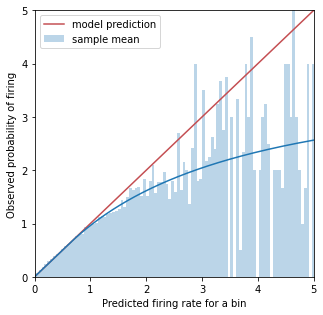

In [399]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

xx = np.linspace(np.log(1e-3), np.log(5), 1000)
plt.plot(np.exp(xx), np.exp(GLM.f_correct(xx, a=-0.15, intecept=-0.5)))

## Plot all effect's output in an example trial

In [400]:
stationary_model_list[3].basis_name

['time_warping_inhomogeneous_baseline',
 'coupling from AM',
 'coupling from PM',
 'coupling from V1',
 'coupling from LM',
 'coupling from AL',
 'coupling from RL',
 'refractory',
 'trial_coef']

In [401]:
to_look_at = 3
import copy
outputs = [stationary_model_list[to_look_at].get_filter_output(ci=False)[i] for i in range(9)]
outputs[to_look_at+1] += outputs[7]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 8):
    total_output += outputs[i]

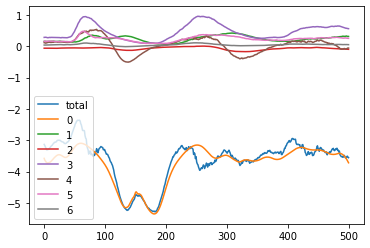

In [402]:
plt.plot(total_output, label='total')
for i, output in enumerate(outputs[:7]):
    plt.plot( output ,label=str(i))
plt.legend()

In [542]:
to_look_at = 3
import copy
model = stationary_model_list[to_look_at]
outputs = [model.get_filter_output(trial_wise=True, ci=False)[i].\
           reshape((model.nt, model.ntrial), order='F')  for i in range(9)]
outputs[to_look_at+1] += outputs[7]
outputs[0] += outputs[8]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]


Text(0.5, 0, 'time (ms)')

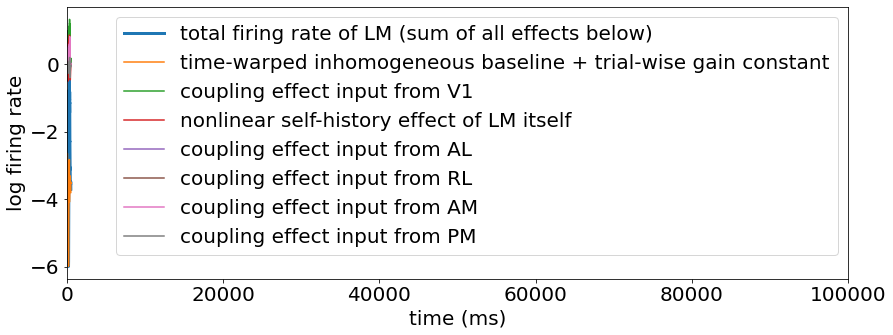

In [404]:
sns.reset_orig()
trial = 1
plot_order = [0,3,4,5,6,1,2]
fontsize = 20

fig, ax = plt.subplots(figsize=(14,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(7):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.legend(['total firing rate of LM (sum of all effects below)', 
            'time-warped inhomogeneous baseline + trial-wise gain constant', 
            'coupling effect input from V1', 
            'nonlinear self-history effect of LM itself', 
            'coupling effect input from AL',
            'coupling effect input from RL',
            'coupling effect input from AM',
            'coupling effect input from PM'], fontsize=fontsize)
plt.xlim([-30, 100000])
plt.ylabel('log firing rate', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

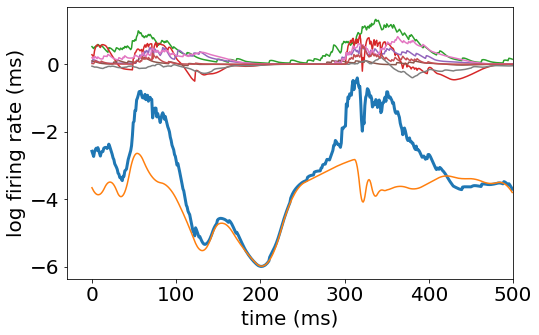

In [548]:
sns.reset_orig()
trial = 1
plot_order = [0,3,4,5,6,1,2]
fontsize = 20

fig, ax = plt.subplots(figsize=(8,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(7):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.xlim([-30, 500])
plt.ylabel('log firing rate (ms)', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)



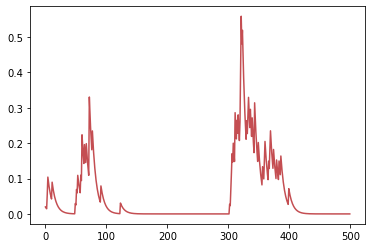

In [586]:
model = stationary_model_list[to_look_at]
plt.plot(model.effect_list[7].reshape((model.nt, model.ntrial), order='F')[:,1], color='r')

# Refractory box (didn't work)

Doesn't work

# Two refractory components with different time constant

In [858]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau1 = 20
tau2 = 50
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau1, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau2, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau1, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau2, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [03:37, 36.23s/it]

AIC improvement of the model is: 2820.7478536787676


Text(0, 0.5, '$f_{refractory}(\\Lambda)$')

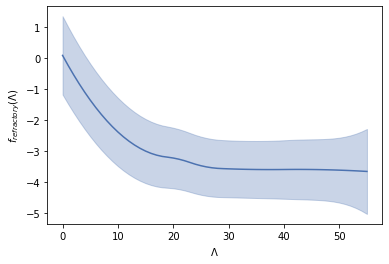

In [862]:
to_look = 8   # 7 or 8
model = stationary_model_list[3]
filters = model.get_filter(ci=True)
one_filter = filters[to_look]
utils.plot_ci(one_filter)
plt.xlabel('$\Lambda$')
plt.ylabel('$f_{refractory}(\Lambda)$')
# plt.ylim([-5, 0])

Text(0.5, 0, 'time (ms)')

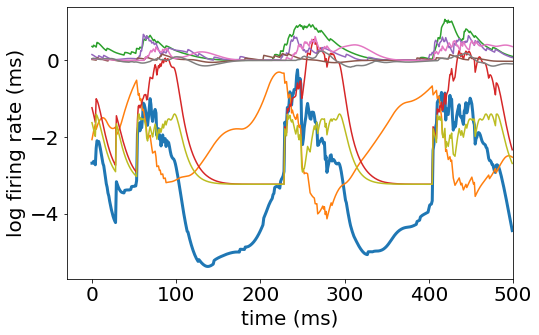

In [852]:
to_look_at = 3
import copy
model = stationary_model_list[to_look_at]
outputs = [model.get_filter_output(trial_wise=True, ci=False)[i].\
           reshape((model.nt, model.ntrial), order='F')  for i in range(9)]
outputs[to_look_at+1] += outputs[7]
outputs[0] += outputs[8]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]

sns.reset_orig()
trial = 85
plot_order = [0,3,4,5,6,1,2, 7]
fontsize = 20

fig, ax = plt.subplots(figsize=(8,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(8):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.xlim([-30, 500])
plt.ylabel('log firing rate (ms)', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

/tmp/ipykernel_59720/776915597.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


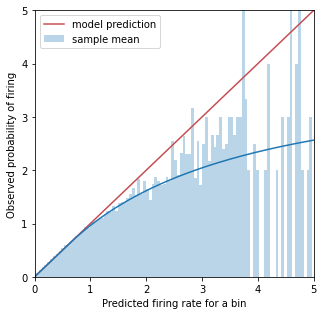

In [748]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

xx = np.linspace(np.log(1e-3), np.log(5), 1000)
plt.plot(np.exp(xx), np.exp(GLM.f_correct(xx, a=-0.15, intecept=-0.5)))

# Refractory with cutoff (didn't work)

doesn't work

# Refractory nonparametric (quantile)

In [856]:
# The following hyperparameters turned out to be the best
num_f_refractory = 5
max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
#     model_stationary.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, method='mine', verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
#     model_running.add_effect('interaction', target_probe, tau=tau, **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, method='mine', verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")

6it [03:35, 35.96s/it]

AIC improvement of the model is: 1733.6660469911294


Text(0, 0.5, '$f_{refractory}(\\Lambda)$')

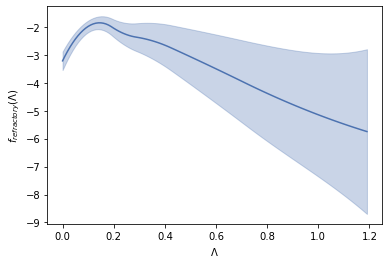

In [857]:
model = stationary_model_list[3]
utils.plot_ci(model.get_filter(ci=True)[7], x=model.f_refractory_xx)
plt.xlabel('$\Lambda$')
plt.ylabel('$f_{refractory}(\Lambda)$')
# plt.ylim([-5, 0])

Text(0.5, 0, 'time (ms)')

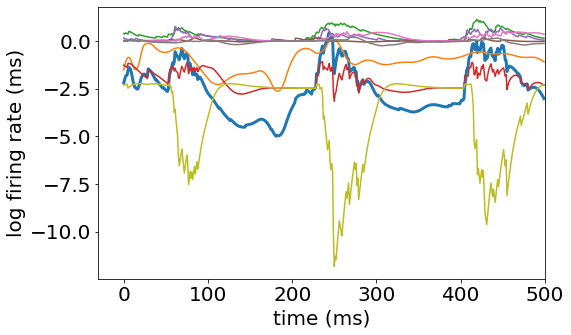

In [750]:
to_look_at = 3
import copy
model = stationary_model_list[to_look_at]
outputs = [model.get_filter_output(trial_wise=True, ci=False)[i].\
           reshape((model.nt, model.ntrial), order='F')  for i in range(9)]
outputs[to_look_at+1] += outputs[7]
outputs[0] += outputs[8]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]

sns.reset_orig()
trial = 85
plot_order = [0,3,4,5,6,1,2, 7]
fontsize = 20

fig, ax = plt.subplots(figsize=(8,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(8):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.xlim([-30, 500])
plt.ylabel('log firing rate (ms)', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

/tmp/ipykernel_59720/776915597.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


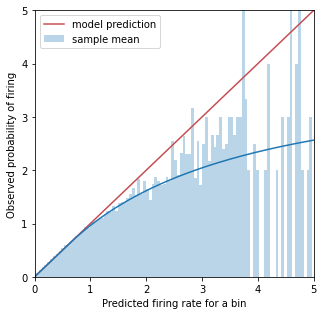

In [748]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

xx = np.linspace(np.log(1e-3), np.log(5), 1000)
plt.plot(np.exp(xx), np.exp(GLM.f_correct(xx, a=-0.15, intecept=-0.5)))

# Additional layer

In [406]:
# The following hyperparameters turned out to be the best

max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                            apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, method='additional', verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory', target_probe, tau=tau, order=1.5, **coupling_filter_params, 
                             apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, method='additional', verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")


6it [03:30, 35.06s/it]

AIC improvement of the model is: 561.1315785261104


/tmp/ipykernel_59720/776915597.py:16: RuntimeWarning: invalid value encountered in true_divide
  plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)


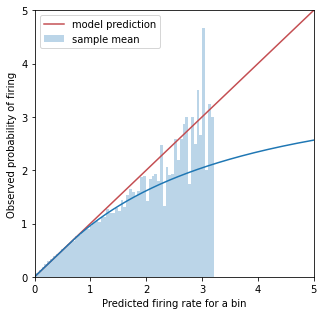

In [407]:
model_list = stationary_model_list + running_model_list

n_bin = 100
dd = 0.05
spike_sum = np.zeros(n_bin)
num_sum = np.zeros(n_bin)
for model in model_list:
    for idata, lmbd in enumerate(np.exp(model.log_lmbd).flatten('F')):
        idx = int(lmbd/dd)
        if idx<n_bin:
            spike_sum[idx] += model.output.flatten('F')[idata]
            num_sum[idx] += 1
xx = np.linspace(0, n_bin*dd, n_bin)
plt.subplots(figsize=(5,4.9))
plt.plot(xx, xx, label='model prediction',color='r')
plt.bar(xx, height=spike_sum/num_sum, width=dd, label='sample mean', alpha=0.3)
plt.legend()
plt.xlabel('Predicted firing rate for a bin')
plt.ylabel('Observed probability of firing')
plt.xlim([0, 5])
plt.ylim([0, 5])

xx = np.linspace(np.log(1e-3), np.log(5), 1000)
plt.plot(np.exp(xx), np.exp(GLM.f_correct(xx, a=-0.15, intecept=-0.5)))

In [415]:
stationary_model_list[3].basis_name

['time_warping_inhomogeneous_baseline',
 'coupling from AM',
 'coupling from PM',
 'coupling from V1',
 'coupling from LM',
 'coupling from AL',
 'coupling from RL',
 'refractory',
 'trial_coef']

In [ ]:
to_look_at = 3
import copy
model = stationary_model_list[to_look_at]
outputs = [model.get_filter_output(trial_wise=True, ci=False)[i].\
           reshape((model.nt, model.ntrial), order='F')  for i in range(9)]
outputs[to_look_at+1] += outputs[7]
outputs[0] += outputs[8]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]

sns.reset_orig()
trial = 5
plot_order = [0,3,4,5,6,1,2]
fontsize = 20

fig, ax = plt.subplots(figsize=(8,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(7):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.xlim([-30, 500])
plt.ylabel('log firing rate (ms)', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

# Refractory nonparametric

In [527]:
# The following hyperparameters turned out to be the best
num_f_refractory = 5
max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    select_trials = V1.stationary_trial_index
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model_stationary.add_effect('refractory_additive', target_probe, tau=30, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model_running.add_effect('refractory_additive', target_probe, tau=30, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")

6it [03:24, 34.02s/it]

AIC improvement of the model is: 665.3608859116212


Text(0, 0.5, '$f_{refractory}(\\Lambda)$')

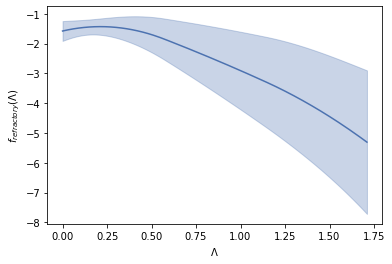

In [532]:
model = running_model_list[2]
utils.plot_ci(model.get_filter(ci=True)[7], x=model.f_refractory_xx)
plt.xlabel('$\Lambda$')
plt.ylabel('$f_{refractory}(\Lambda)$')
# plt.ylim([-5, 0])

Text(0.5, 0, 'time (ms)')

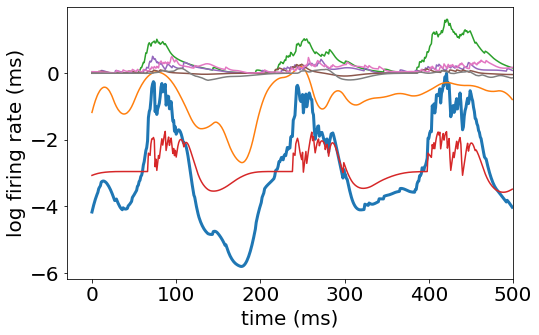

In [540]:
to_look_at = 3
import copy
model = stationary_model_list[to_look_at]
outputs = [model.get_filter_output(trial_wise=True, ci=False)[i].\
           reshape((model.nt, model.ntrial), order='F')  for i in range(9)]
outputs[to_look_at+1] += outputs[7]
outputs[0] += outputs[8]
total_output = copy.deepcopy( outputs[0] )
for i in range(1, 7):
    total_output += outputs[i]

sns.reset_orig()
trial = 5
plot_order = [0,3,4,5,6,1,2]
fontsize = 20

fig, ax = plt.subplots(figsize=(8,5))
ax.tick_params(axis='both', which='major', labelsize=fontsize)
plt.plot(total_output[:,trial], label='total', linewidth=3)
for i in range(7):
    output = outputs[plot_order[i]]
    plt.plot( output[:,trial], linewidth=1.5)
# plt.legend(['total firing rate of V1 (sum of all effects below)', 
#             'time-warped inhomogeneous baseline + trial-wise gain constant', 
#             'nonlinear self-history effect of V1', 
#             'coupling effect input from LM',
#             'coupling effect input from AL',
#             'coupling effect input from RL',
#             'coupling effect input from AM',
#             'coupling effect input from PM'])
plt.xlim([-30, 500])
plt.ylabel('log firing rate (ms)', fontsize=fontsize)
plt.xlabel('time (ms)', fontsize=fontsize)

In [ ]:
# The following hyperparameters turned out to be the best
num_f_refractory = 15
max_iter = 10
self_effect = False
tau = 10
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
coupling_filter_params1 = {'peaks_max':20, 'num':2, 'nonlinear':0.3}
coupling_filter_params2 = {'peaks_max':50, 'num':5, 'nonlinear':0.3}
num_basis_baseline = 30
penalty = 3e-1

########## Nothing need to be changed below
probe_list = V1.selected_probes
select_trials = V1.stationary_trial_index
running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)): 
    model_stationary = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_stationary.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_stationary.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_stationary.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_stationary.add_effect('trial_coef')
    model_stationary.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model_stationary)
    
    select_trials = V1.running_trial_index
    model_running = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model_running.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model_running.add_effect('coupling', probe_list[j], **coupling_filter_params, apply_no_penalty=True)
    model_running.add_effect('refractory_additive', target_probe, tau=tau, num=num_f_refractory, apply_no_penalty=True)
    model_running.add_effect('trial_coef')
    model_running.fit_time_warping_baseline(target_probe, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model_running)
    
aic = np.sum([model.aic for model in stationary_model_list]+[model.aic for model in running_model_list])

print(f"AIC improvement of the model is: {2*(baseline_aic - aic)}")